$$
\begin{array}{c}
\textbf{CAUSAL INFERENCE (DS-UA 201)}\\\\
\textbf{Lab: Experiments 3 Recap + Regression 1} \\\\
\end{array}
$$

---

# Part 1: Recap of Experiments 3 (SUTVA and Cluster Randomization)

**How do we test for, and cope with, failures of SUTVA?**

### Testing SUTVA

- There is no general-purpose test. You have to think about the **specific way** SUTVA could fail in the specific experiment.
  - *Example (LaLonde):* training the treated group could change the local labor market, which would affect the control group's job prospects too.
- A practical approach: **follow up with subjects** and check whether the violation you're worried about actually happened. 

### Spillovers

The most common SUTVA violation is a **spillover**: treating some units affects untreated units. The treatment effect "spills over" onto the control group.

Why that's a problem: the control group is partly affected by treatment, so comparing treated and control units no longer gives a "pure" estimate of the effect of treatment.

### Cluster randomized trials

Spillovers are often contained within a group (a class, family, school, town, village). If so, we can **randomize at the group level instead of the individual level**: each group is either entirely treated or entirely untreated.

Let $S_G$ be group-level treatment. If $S_G \perp U$, then

$$E[Y(S_G = 1, U) - Y(S_G = 0, U)] = E[Y(S_G = 1, U) \mid S_G = 1] - E[Y(S_G = 0, U) \mid S_G = 0],$$

which is identified by the same argument we used for the ATE in an ordinary experiment.

**Important:** this is a *different parameter* from the ATE. It includes **both the direct effect of treatment and the effect of spillovers**, and the design generally cannot separate the two.


---

# Part 2: Regression 1: Descriptive vs. Causal Regression

Linear regression is one of the workhorse tools of empirical work. In lecture we saw that the *same equation* can be read in two very different ways:

| | **Descriptive regression** | **Causal regression** |
|---|---|---|
| Equation | $Y = \beta_0 + \beta_1 X + \varepsilon$ | $Y(S,U) = \alpha_0 + \alpha_1 S + U$ |
| What the parameters mean | The **best linear predictor** of $Y$ given $X$ | The causal effect of the state $S$ on $Y$ (in a linear all-causes model) |
| What the residual means | Just the prediction error, no interpretation | **All other causes** of $Y$ besides $S$ |
| Always identified? | **Yes** (as long as $\text{Var}(X) > 0$) | **Only if** $E[SU] = 0$ (e.g. when $S \perp U$) |

**Plan**
1. Descriptive regression and the best linear predictor
2. Residuals: what they are and the two properties they always satisfy
3. Identification: $\beta_1 = \text{Cov}(X,Y)/\text{Var}(X)$ and $\beta_0 = E[Y] - \beta_1 E[X]$
4. Good fits vs. bad fits
5. The "linear" in best *linear* predictor, and how transforming variables helps
6. Causal regression: when the slope is a causal effect, and when it is not

## 0. Setup

We only need three standard libraries for this lab.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

rng = np.random.default_rng(201)

plt.rcParams["figure.figsize"] = (7, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

## 1. Descriptive regression: the best linear predictor

In a descriptive regression
$$Y = \beta_0 + \beta_1 X + \varepsilon,$$
$\beta_0$ and $\beta_1$ are defined as the values of $b_0, b_1$ that solve
$$\min_{b_0, b_1} \; E\big[(Y - (b_0 + b_1 X))^2\big].$$

In words: among all straight lines, pick the one that makes the average squared prediction error as small as possible. These parameters exist for any pair of jointly distributed variables, causal or not, just like a correlation does.

### Example: ice cream and crime

Example is predicting crime with ice cream sales. Ice cream has no causal effect on crime, but both go up on hot days. Temperature drives both variables, and ice cream sales do not appear in the equation for crime at all.

In [2]:
n = 1000

temperature = rng.normal(loc=70, scale=12, size=n)
ice_cream = 20 + 3.0 * temperature + rng.normal(0, 15, size=n)
crime = 5 + 0.8 * temperature + rng.normal(0, 8, size=n)

df = pd.DataFrame({"temperature": temperature,
                   "ice_cream": ice_cream,
                   "crime": crime})
df.head()

,temperature,ice_cream,crime
0,93.147486,307.862964,73.203774
1,62.707810,180.512316,60.050744
2,45.139609,156.036198,34.368622
3,60.387884,202.562004,62.624347
4,90.722880,280.405006,73.967286


### Estimating $\beta_0$ and $\beta_1$

Descriptive regression parameters are identified as
$$\beta_1 = \frac{\text{Cov}(X,Y)}{\text{Var}(X)}, \qquad \beta_0 = E[Y] - \beta_1 E[X].$$

With an iid sample we can estimate each piece with its sample analogue (sample covariance, sample variance, sample means) and plug them in. A small function we can reuse throughout the notebook:

In [3]:
def blp(x, y):
    cov_xy = np.cov(x, y, ddof=1)[0, 1]
    var_x = np.var(x, ddof=1)
    beta_1 = cov_xy / var_x
    beta_0 = np.mean(y) - beta_1 * np.mean(x)
    return beta_0, beta_1

b0_hat, b1_hat = blp(df["ice_cream"], df["crime"])
print(f"Estimated beta_0 = {b0_hat:.3f}")
print(f"Estimated beta_1 = {b1_hat:.3f}")

Estimated beta_0 = 8.722
Estimated beta_1 = 0.227


### Code explained

- `def blp(x, y):` defines a function called `blp` (short for *best linear predictor*) that takes a predictor `x` and an outcome `y`.
- `np.cov(x, y, ddof=1)` returns a 2×2 **covariance matrix**: the top-left entry is $\text{Var}(x)$, the bottom-right is $\text{Var}(y)$, and the off-diagonal entries are $\text{Cov}(x,y)$. `[0, 1]` picks out the off-diagonal entry, the covariance we want. `ddof=1` means divide by $n-1$ (the usual sample formula).
- `np.var(x, ddof=1)` is the sample variance of `x`, also dividing by $n-1$ so it matches the covariance. (Any matching choice works, since the $n$'s cancel in the ratio.)
- `beta_1 = cov_xy / var_x` is the slope formula $\text{Cov}(X,Y)/\text{Var}(X)$.
- `beta_0 = np.mean(y) - beta_1 * np.mean(x)` is the intercept formula $E[Y] - \beta_1 E[X]$, using sample means.
- `return beta_0, beta_1` hands both numbers back.
- `b0_hat, b1_hat = blp(df["ice_cream"], df["crime"])` runs the function on our data and stores the two results. The "hat" in the names is the usual notation for an *estimate*.
- The `print(f"...{b1_hat:.3f}")` lines print each estimate rounded to 3 decimal places. The `f` before the string lets us put variables inside `{}`.

### Interpretation

The slope is clearly positive: days with more ice cream sales tend to have more crime, and the line tells us how much crime to *predict* for a given level of sales. That is a perfectly valid descriptive statement, but it is **not** a causal statement. We built this world so that ice cream has zero effect on crime; the positive slope comes entirely from both variables rising with temperature. Keep this in mind for Section 6.

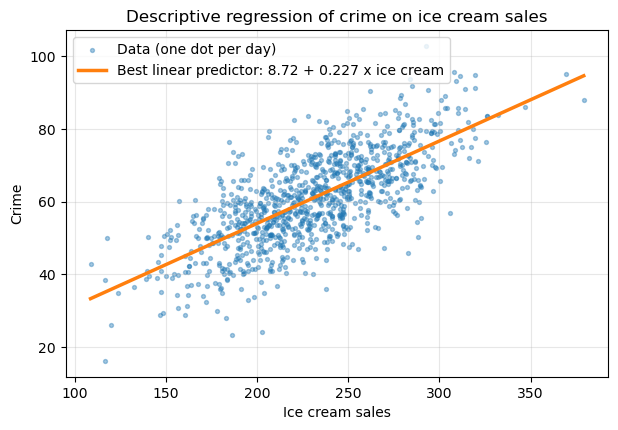

In [4]:
grid = np.linspace(df["ice_cream"].min(), df["ice_cream"].max(), 100)

plt.scatter(df["ice_cream"], df["crime"], s=8, alpha=0.4, label="Data (one dot per day)")
plt.plot(grid, b0_hat + b1_hat * grid, color="C1", linewidth=2.5,
         label=f"Best linear predictor: {b0_hat:.2f} + {b1_hat:.3f} x ice cream")
plt.xlabel("Ice cream sales")
plt.ylabel("Crime")
plt.title("Descriptive regression of crime on ice cream sales")
plt.legend()
plt.show()

### Checking that the formula really minimizes the squared error

The formula $\text{Cov}(X,Y)/\text{Var}(X)$ came from solving the minimization problem with first-order conditions. Let's check it the manual way: try *many* candidate lines, compute the average squared error of each, and see which one wins.

In [5]:
x = df["ice_cream"].to_numpy()
y = df["crime"].to_numpy()

b0_candidates = np.linspace(b0_hat - 10, b0_hat + 10, 201)
b1_candidates = np.linspace(b1_hat - 0.1, b1_hat + 0.1, 201)

best_mse, best_b0, best_b1 = np.inf, None, None
for b0 in b0_candidates:
    for b1 in b1_candidates:
        mse = np.mean((y - (b0 + b1 * x)) ** 2)
        if mse < best_mse:
            best_mse, best_b0, best_b1 = mse, b0, b1

print(f"Grid search winner : b0 = {best_b0:.3f}, b1 = {best_b1:.4f}, MSE = {best_mse:.3f}")
print(f"Formula (Cov/Var)  : b0 = {b0_hat:.3f}, b1 = {b1_hat:.4f}, "
      f"MSE = {np.mean((y - (b0_hat + b1_hat * x)) ** 2):.3f}")

Grid search winner : b0 = 8.722, b1 = 0.2266, MSE = 76.807
Formula (Cov/Var)  : b0 = 8.722, b1 = 0.2266, MSE = 76.807


### Code explained

- `.to_numpy()` converts the pandas columns into plain NumPy arrays, which are faster inside loops.
- `b0_candidates` and `b1_candidates` are 201 evenly spaced guesses for the intercept and slope, centered on our formula's answers. That is 201 × 201 = 40,401 candidate lines in total.
- `best_mse, best_b0, best_b1 = np.inf, None, None` initializes the "best so far". Starting `best_mse` at infinity (`np.inf`) guarantees the first line we try will beat it.
- The two nested `for` loops visit every combination of `b0` and `b1`.
- `mse = np.mean((y - (b0 + b1 * x)) ** 2)` is the **sample version of the objective** $E[(Y - (b_0 + b_1X))^2]$: compute each day's prediction error, square it, and average.
- `if mse < best_mse:` keeps a candidate only if it beats the best seen so far.

### Interpretation

The search lands on (essentially) the same line as the formula, and no candidate on the grid has a smaller average squared error. The tiny differences are only because the grid has finite spacing. So $\text{Cov}/\text{Var}$ really is the solution to the minimization problem.

## 2. Descriptive residuals

The residual is **defined** as how far off the prediction is:
$$\varepsilon \equiv Y - (\beta_0 + \beta_1 X).$$

### The two properties residuals always satisfy

Taking first-order conditions of the minimization problem gave us

$$\frac{d}{db_0}: \quad E[Y - b_0 - b_1 X] = 0 \qquad\Longrightarrow\qquad E[\varepsilon] = 0$$
$$\frac{d}{db_1}: \quad E[X(Y - b_0 - b_1 X)] = 0 \qquad\Longrightarrow\qquad E[X\varepsilon] = 0$$

These hold by definition for any descriptive regression, on any data. They are consequences of choosing the line that minimizes squared error. Let's confirm both in our sample.

In [6]:
residuals = y - (b0_hat + b1_hat * x)

print(f"Sample mean of residuals,        mean(eps)   = {np.mean(residuals):.2e}")
print(f"Sample mean of X times residual, mean(X*eps) = {np.mean(x * residuals):.2e}")

Sample mean of residuals,        mean(eps)   = -3.04e-15
Sample mean of X times residual, mean(X*eps) = -1.08e-12


### Code explained

- `residuals = y - (b0_hat + b1_hat * x)` computes $\hat\varepsilon_i = y_i - (\hat\beta_0 + \hat\beta_1 x_i)$ for every observation at once (NumPy does the subtraction element by element).
- `np.mean(residuals)` is the sample analogue of $E[\varepsilon]$.
- `np.mean(x * residuals)` multiplies each $x_i$ by its own residual and averages, the sample analogue of $E[X\varepsilon]$.
- `:.2e` prints the number in scientific notation with 2 decimals, which is the clearest way to display very tiny numbers.

### Interpretation

Both numbers are on the order of $10^{-12}$ or smaller, which is zero up to computer rounding error. This will happen with any data you feed into `blp`, which is exactly why descriptive regression parameters are always identified.

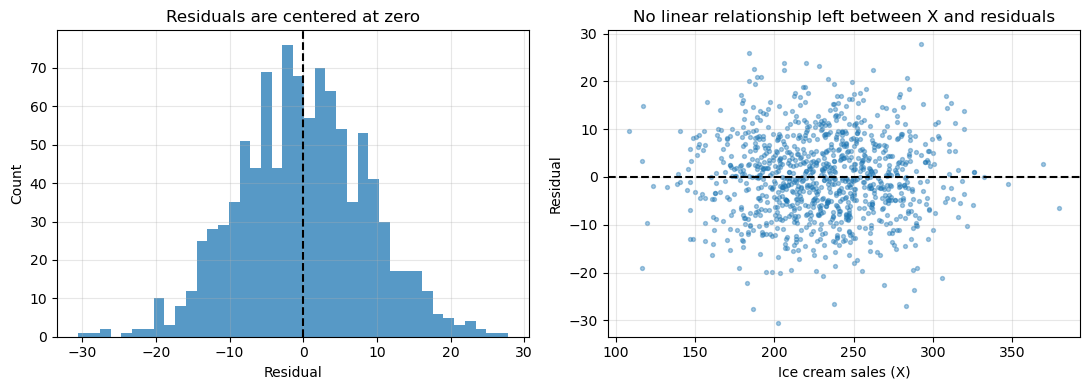

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(residuals, bins=40, color="C0", alpha=0.75)
axes[0].axvline(0, color="black", linestyle="--")
axes[0].set_title("Residuals are centered at zero")
axes[0].set_xlabel("Residual")
axes[0].set_ylabel("Count")

axes[1].scatter(x, residuals, s=8, alpha=0.4)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_title("No linear relationship left between X and residuals")
axes[1].set_xlabel("Ice cream sales (X)")
axes[1].set_ylabel("Residual")

plt.tight_layout()
plt.show()

## 3. Identification, step by step

The slides used the two residual conditions to solve for the parameters:

**Step 1 (intercept).** From $E[\varepsilon]=0$:
$$E[Y] - \beta_0 - \beta_1 E[X] = 0 \quad\Longrightarrow\quad \beta_0 = E[Y] - \beta_1 E[X].$$

**Step 2 (slope).** Substitute $\beta_0$ into $E[X\varepsilon]=0$ and rearrange:
$$E[X(Y - E[Y])] - \beta_1 E[X(X - E[X])] = 0.$$

**Step 3.** Recognize the two pieces:
$$E[X(Y - E[Y])] = E[XY] - E[X]E[Y] = \text{Cov}(X,Y), \qquad E[X(X - E[X])] = \text{Var}(X).$$

So $\text{Cov}(X,Y) - \beta_1 \text{Var}(X) = 0$, giving
$$\boxed{\beta_1 = \frac{\text{Cov}(X,Y)}{\text{Var}(X)}} \qquad (\text{requires } \text{Var}(X) > 0).$$



### Why $\text{Var}(X) > 0$ matters

If $X$ never varies, the formula divides by zero. Intuitively, if every observation has the same $X$, there is no way to learn how $Y$ changes as $X$ changes. The cell below shows what NumPy does in that case.

In [8]:
x_constant = np.full(n, 50.0)

with np.errstate(divide="ignore", invalid="ignore"):
    print(blp(x_constant, y))

(nan, nan)



### Interpretation

The result is `nan` ("not a number"). The slope is not identified, and therefore neither is the intercept, which depends on it.

## 4. Good fits and bad fits

Because descriptive regression is always identified, you can regress anything on anything. But *how good* the best linear predictor is depends on the variables. Models that fit well have small residuals.

The slides compared two models:
$$\text{Rainfall} = \beta^1_0 + \beta^1_1 \,\%\text{Cloud Cover} + \varepsilon^1$$
$$\text{Rainfall} = \beta^2_0 + \beta^2_1 \,\text{Day of the Month} + \varepsilon^2$$

Let's simulate a world where cloud cover strongly predicts rainfall and the day of the month is irrelevant, then compare the residuals.

In [9]:
cloud_cover = rng.uniform(0, 100, size=n)
day_of_month = rng.integers(1, 31, size=n)
rainfall = 0.05 * cloud_cover + rng.normal(0, 0.6, size=n)

a0, a1 = blp(cloud_cover, rainfall)
c0, c1 = blp(day_of_month, rainfall)

resid_cloud = rainfall - (a0 + a1 * cloud_cover)
resid_day = rainfall - (c0 + c1 * day_of_month)

pd.DataFrame({
    "Predictor": ["% cloud cover", "Day of the month"],
    "beta_0 hat": [a0, c0],
    "beta_1 hat": [a1, c1],
    "Residual std. dev.": [resid_cloud.std(), resid_day.std()],
}).round(3)

,Predictor,beta_0 hat,beta_1 hat,Residual std. dev.
0,% cloud cover,0.027,0.050,0.605
1,Day of the month,2.566,-0.006,1.531



### Interpretation

Both regressions run without complaint and both produce a best linear predictor. But the cloud-cover model's residuals are much smaller. The day-of-month slope is near zero and its residuals are about as spread out as rainfall itself, meaning the "best" line is barely better than just predicting average rainfall every day. "Best" only means best among lines using *that* predictor.

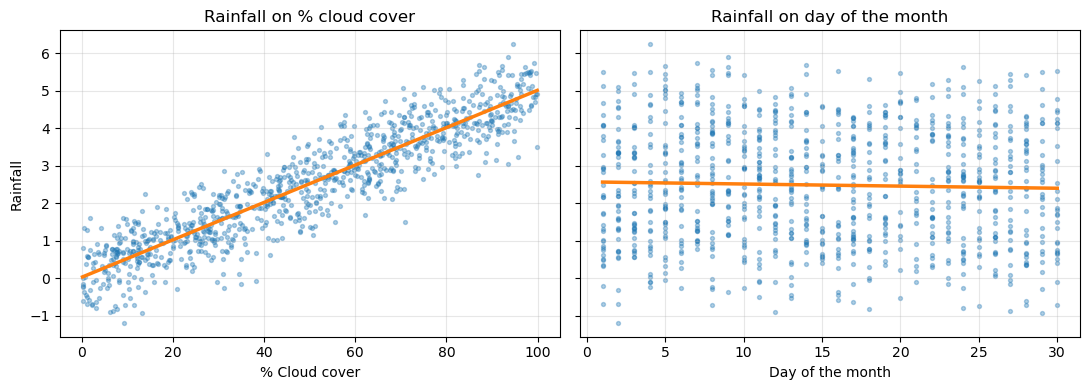

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, xv, b0, b1, name in [(axes[0], cloud_cover, a0, a1, "% Cloud cover"),
                             (axes[1], day_of_month, c0, c1, "Day of the month")]:
    ax.scatter(xv, rainfall, s=8, alpha=0.35)
    xs = np.linspace(xv.min(), xv.max(), 100)
    ax.plot(xs, b0 + b1 * xs, color="C1", linewidth=2.5)
    ax.set_xlabel(name)
    ax.set_title(f"Rainfall on {name.lower()}")
axes[0].set_ylabel("Rainfall")

plt.tight_layout()
plt.show()


### Interpretation

On the left the points hug the line (small residuals); on the right the line is flat and the points are scattered far from it (big residuals).

## 5. The best *linear* predictor, and transforming variables

Regression finds the best straight line. If the true relationship is curved, the best line can be a poor predictor.

Let $X \sim N(0,1)$ and $Y = X^2$. 

Here $Y$ is a *perfect* function of $X$, yet the best linear predictor is (in the population) $\beta_0 + \beta_1 X = 1$, a flat line.

 Why? Because $X$ is symmetric around zero, $\text{Cov}(X, X^2) = E[X^3] - E[X]E[X^2] = 0$, so $\beta_1 = 0$, and then $\beta_0 = E[Y] = E[X^2] = 1$.

In [11]:
n_big = 20000
x_sym = rng.normal(0, 1, size=n_big)
y_sq = x_sym ** 2

d0, d1 = blp(x_sym, y_sq)
print(f"Regress Y on X:   beta_0 hat = {d0:.3f}, beta_1 hat = {d1:.3f}")
print(f"Residual std. dev. = {np.std(y_sq - (d0 + d1 * x_sym)):.3f}")

Regress Y on X:   beta_0 hat = 0.985, beta_1 hat = -0.036
Residual std. dev. = 1.403


### Code explained

- `n_big = 20000
x_sym = rng.normal(0, 1, size=n_big)` draws $X$ from a standard normal (mean 0, standard deviation 1).
- `y_sq = x_sym ** 2` sets $Y = X^2$ exactly, with no noise at all. (`**` is Python's power operator.)
- `blp(x_sym, y_sq)` fits the best linear predictor of $Y$ given $X$.
- The second `print` reports how large the residuals are.

### Interpretation

The estimates are close to the population values $\beta_0 = 1$, $\beta_1 = 0$ (not exactly, because this is a sample of 1,000 draws). Even though $X$ determines $Y$ perfectly, the best *line* is essentially flat and the residuals are large.

### Transforming the predictor

Linearity is less restrictive than it sounds, because we can transform variables before running the regression. If we create a new variable $Z = X^2$ and regress $Y$ on $Z$, the model is still linear *in the parameters*, $Y = \beta_0 + \beta_1 Z + \varepsilon$, but now it can capture the curve.

Regress Y on X^2: beta_0 hat = -0.000, beta_1 hat = 1.000
Residual std. dev. = 6.45e-16


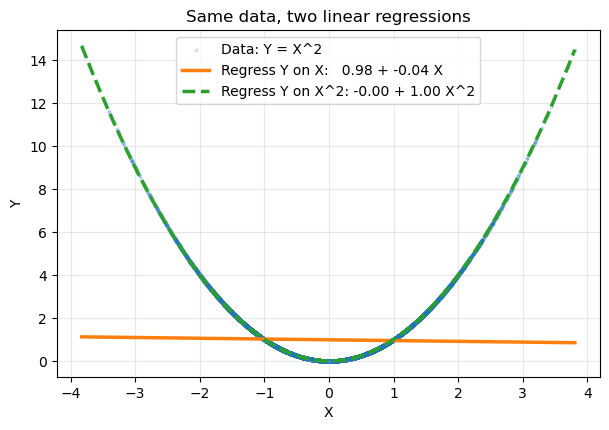

In [12]:
z = x_sym ** 2

e0, e1 = blp(z, y_sq)
print(f"Regress Y on X^2: beta_0 hat = {e0:.3f}, beta_1 hat = {e1:.3f}")
print(f"Residual std. dev. = {np.std(y_sq - (e0 + e1 * z)):.2e}")

order = np.argsort(x_sym)
plt.scatter(x_sym, y_sq, s=4, alpha=0.15, label="Data: Y = X^2")
plt.plot(x_sym[order], d0 + d1 * x_sym[order], color="C1", linewidth=2.5,
         label=f"Regress Y on X:   {d0:.2f} + {d1:.2f} X")
plt.plot(x_sym[order], e0 + e1 * z[order], color="C2", linewidth=2.5, linestyle="--",
         label=f"Regress Y on X^2: {e0:.2f} + {e1:.2f} X^2")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Same data, two linear regressions")
plt.legend()
plt.show()


### Interpretation

Regressing on $X^2$ gives $\hat\beta_0 = 0$ and $\hat\beta_1 = 1$ (up to rounding error), so the prediction is exactly $X^2$ and the residuals are essentially zero: perfect prediction, just like the slide. The method was the same both times, but choosing the right transformation of the variable made the difference.

## 6. Causal regression

Now we read the regression equation as an **all-causes model**:
$$Y(S, U) = \alpha_0 + \alpha_1 S + U.$$

Two important differences from the descriptive case:

1. This only makes sense if the all-causes model really is linear.
2. $U$ is no longer "whatever the line misses". all the other causes of $Y$ besides $S$.

### $E[U] = 0$ is free

If $E[U] \neq 0$, define $\tilde\alpha_0 \equiv \alpha_0 + E[U]$ and $\tilde U \equiv U - E[U]$. Then
$$Y = \alpha_0 + \alpha_1 S + U = \tilde\alpha_0 + \alpha_1 S + \tilde U, \qquad E[\tilde U] = 0.$$
Any nonzero mean of $U$ just gets folded into the intercept, and the slope $\alpha_1$ is untouched. So we can always assume $E[U]=0$ without loss of generality.

### $E[SU] = 0$ is not free

For descriptive regression, $E[X\varepsilon]=0$ held by definition. For causal regression, $E[SU] = 0$ is a substantive assumption about the world. It holds, for example, when $S \perp U$:
$$E[SU] = E\big[E[SU \mid S]\big] = E\big[S\,E[U \mid S]\big] = E\big[S\,E[U]\big] = E[S \cdot 0] = 0.$$

If it fails, $\text{Cov}(S,Y)/\text{Var}(S)$ is still a perfectly good *descriptive* slope, but it is not $\alpha_1$.

### Simulation: college and income

Let $Y$ = income and $S$ = 1 if a person goes to college. We will set the true causal effect of college to $\alpha_1 = 10$ (thousand dollars). $U$ collects all other causes of income; here we model it as something like "background advantages" (family resources, connections, etc.).

We'll simulate two worlds with the same causal model and compare what regression finds:
- **World A:** college is assigned at random, so $S \perp U$.
- **World B:** people with more background advantages are more likely to attend college, so $S$ and $U$ are related.

In [13]:
alpha_0, alpha_1 = 40.0, 10.0

U = rng.normal(0, 8, size=n)

S_random = rng.binomial(1, 0.5, size=n)
Y_random = alpha_0 + alpha_1 * S_random + U

prob_college = 1 / (1 + np.exp(-U / 4))
S_selected = rng.binomial(1, prob_college)
Y_selected = alpha_0 + alpha_1 * S_selected + U

print(f"True causal effect alpha_1 = {alpha_1}")

True causal effect alpha_1 = 10.0


### Code explained

- `alpha_0, alpha_1 = 40.0, 10.0` sets the true parameters: baseline income of 40 (thousand dollars) without college, and a causal effect of college of +10.
- `U = rng.normal(0, 8, size=n)` draws each person's "other causes" of income. It has mean 0, matching $E[U]=0$.
- **World A:**
  - `rng.binomial(1, 0.5, size=n)` flips a fair coin for each person: 1 (college) with probability 0.5, otherwise 0. The coin knows nothing about `U`, so $S \perp U$.
  - `Y_random = alpha_0 + alpha_1 * S_random + U` generates income from the all-causes model.
- **World B:**
  - `prob_college = 1 / (1 + np.exp(-U / 4))` turns each person's `U` into a probability between 0 and 1 (this S-shaped function is called the *logistic* function). Higher `U` means a higher chance of college. Dividing by 4 just controls how strongly `U` matters.
  - `rng.binomial(1, prob_college)` then gives each person their own coin with their own probability. Now $S$ depends on $U$.
  - `Y_selected = ...` uses **the exact same causal model and the same `U`** as World A. Only who goes to college has changed.

In [14]:
pd.set_option("display.width", 200)

results = []
for world, S, Y in [("A: random assignment (S independent of U)", S_random, Y_random),
                    ("B: selection on U", S_selected, Y_selected)]:
    beta_0_hat, beta_1_hat = blp(S, Y)
    results.append({
        "World": world,
        "Sample mean of S*U": np.mean(S * U),
        "Regression slope": beta_1_hat,
        "True alpha_1": alpha_1,
    })

pd.DataFrame(results).round(3)

,World,Sample mean of S*U,Regression slope,True alpha_1
0,A: random assignment (S independent of U),-0.10,10.400,10.0
1,B: selection on U,2.23,19.708,10.0




### Interpretation

- **World A:** $E[SU] \approx 0$, and the regression slope is close to the true effect of 10. (Not exactly 10, because this is a finite sample.) Random assignment made the descriptive slope equal the causal parameter.
- **World B:** $E[SU]$ is clearly positive, and the slope is far above 10. The regression is mixing the effect of college with the fact that college-goers have more background advantages. In the slides' words, $E[SU]=0$ would require that college-goers have otherwise identical incomes to non-college-goers, and in World B they don't.

The slope in World B is still a valid **descriptive** number (the best linear predictor of income given college). It just isn't the **causal** effect.

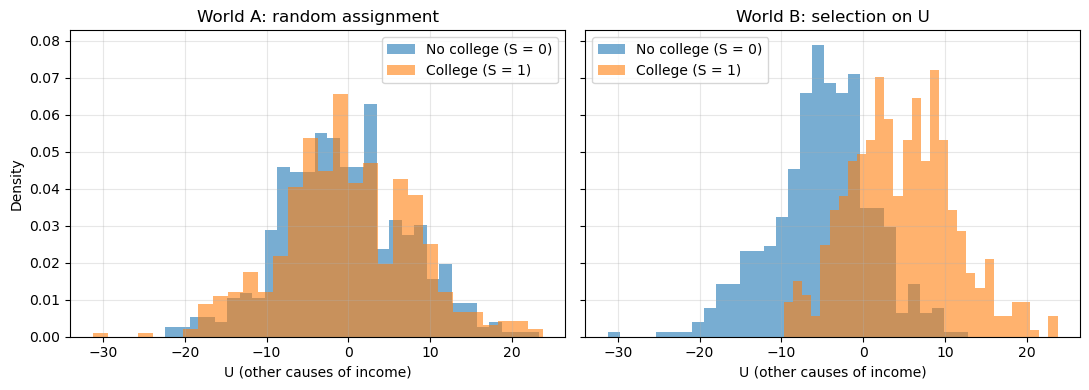

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, S, title in [(axes[0], S_random, "World A: random assignment"),
                     (axes[1], S_selected, "World B: selection on U")]:
    ax.hist(U[S == 0], bins=30, alpha=0.6, density=True, label="No college (S = 0)")
    ax.hist(U[S == 1], bins=30, alpha=0.6, density=True, label="College (S = 1)")
    ax.set_title(title)
    ax.set_xlabel("U (other causes of income)")
    ax.legend()
axes[0].set_ylabel("Density")

plt.tight_layout()
plt.show()


### Interpretation

This is the picture behind $S \perp U$. In World A the two groups have the same distribution of other causes, so comparing their incomes isolates the effect of college. In World B college-goers are shifted to the right: they would have earned more even without college, and regression attributes that difference to $S$.

In [16]:
U_shifted = U + 5
Y_shifted = alpha_0 + alpha_1 * S_random + U_shifted

g0, g1 = blp(S_random, Y_shifted)
print(f"Mean of U_shifted          = {np.mean(U_shifted):.3f}")
print(f"Regression intercept       = {g0:.3f}   (alpha_0 + mean of U_shifted = {alpha_0 + np.mean(U_shifted):.3f})")
print(f"Regression slope           = {g1:.3f}   (true alpha_1 = {alpha_1})")

Mean of U_shifted          = 4.599
Regression intercept       = 44.399   (alpha_0 + mean of U_shifted = 44.599)
Regression slope           = 10.400   (true alpha_1 = 10.0)


This cell checks the "$E[U]=0$ is free" argument from above.

### Interpretation

The intercept absorbs the mean of $U$ (roughly 45 instead of 40), exactly as in the $\tilde\alpha_0 = \alpha_0 + E[U]$ argument, while the slope is unchanged. The mean of $U$ is harmless; what matters for the slope is whether $S$ is related to $U$.

## 7. Relation to ice cream example

We can now restate the Section 1 result in causal language. In our simulated world, ice cream has **zero** causal effect on crime, yet the descriptive slope was clearly positive. Thinking of temperature as part of $U$ (the other causes of crime), ice cream sales are strongly related to $U$, so $E[SU] \neq 0$ and the slope cannot be read causally.

In [17]:
other_causes_of_crime = crime - 5
print(f"Correlation between ice cream and other causes of crime = "
      f"{np.corrcoef(ice_cream, other_causes_of_crime)[0, 1]:.3f}")
print(f"Descriptive slope (from Section 1)                        = {b1_hat:.3f}")
print(f"True causal effect of ice cream on crime                  = 0")

Correlation between ice cream and other causes of crime = 0.717
Descriptive slope (from Section 1)                        = 0.227
True causal effect of ice cream on crime                  = 0


### Code explained

- `other_causes_of_crime = crime - 5` recovers everything that determines crime other than the constant. Since ice cream's true effect is zero, this is all of $U$ for crime (temperature's influence plus noise). We can only do this because we wrote the simulation.
- `np.corrcoef(a, b)` returns a 2×2 correlation matrix; `[0, 1]` is the correlation between the two variables.
- The other two lines print the slope from Section 1 and the true effect for comparison.

### Interpretation

Ice cream is strongly correlated with crime's other causes, which is exactly the failure of $E[SU] = 0$. The regression is a fine predictor and a misleading causal estimate.

## Summary

**Descriptive regression**
- $\beta_0, \beta_1$ define the best linear predictor of $Y$ given $X$: they minimize $E[(Y - (b_0 + b_1X))^2]$.
- The residual $\varepsilon$ is just the prediction error. $E[\varepsilon]=0$ and $E[X\varepsilon]=0$ hold by definition (they are the first-order conditions).
- So the parameters are always identified when $\text{Var}(X) > 0$:
  $\beta_1 = \text{Cov}(X,Y)/\text{Var}(X)$, $\beta_0 = E[Y] - \beta_1E[X]$, and we estimate them with sample analogues.
- Some predictors fit well (small residuals), some badly. "Best" is only best among straight lines in that predictor; transforming variables (e.g. using $X^2$) can fix a curved relationship.

**Causal regression**
- $Y(S,U) = \alpha_0 + \alpha_1 S + U$ only makes sense if the all-causes model is linear, and $U$ means all other causes of $Y$.
- $E[U] = 0$ is a harmless normalization (the mean folds into the intercept).
- $E[SU] = 0$ is a substantive assumption that holds, for example, when $S \perp U$. Without it, the regression slope is a valid descriptive number but not the causal effect.
- With observational data we cannot read regressions like crime-on-ice-cream or income-on-college causally, unless we have a reason to believe $S \perp U$ (as in a randomized experiment).


## Exercise 1: Build the slope from means only

In Section 3 we showed that
$$\beta_1 = \frac{E[XY] - E[X]E[Y]}{E[X^2] - E[X]^2}, \qquad \beta_0 = E[Y] - \beta_1 E[X].$$

**Task.** Write a function `blp_means(x, y)` that estimates $\beta_0$ and $\beta_1$ using **only `np.mean`** (no `np.cov` or `np.var`). Then check that it gives the same answers as `blp` for:
1. crime on ice cream (`ice_cream`, `crime`), and
2. rainfall on cloud cover (`cloud_cover`, `rainfall`).

In [18]:
def blp_means(x, y):
    cov_xy = ___                      # E[XY] - E[X]E[Y]
    var_x = ___                       # E[X^2] - E[X]^2
    beta_1 = ___
    beta_0 = ___
    return beta_0, beta_1

print("Ice cream -> crime   :", blp_means(ice_cream, crime), "vs", blp(ice_cream, crime))
print("Cloud cover -> rain  :", blp_means(cloud_cover, rainfall), "vs", blp(cloud_cover, rainfall))

Ice cream -> crime   : (   temperature   ice_cream      crime
0    93.147486  307.862964  73.203774
1    62.707810  180.512316  60.050744
2    45.139609  156.036198  34.368622
3    60.387884  202.562004  62.624347
4    90.722880  280.405006  73.967286,    temperature   ice_cream      crime
0    93.147486  307.862964  73.203774
1    62.707810  180.512316  60.050744
2    45.139609  156.036198  34.368622
3    60.387884  202.562004  62.624347
4    90.722880  280.405006  73.967286) vs (8.721514862205005, 0.2265594307898363)
Cloud cover -> rain  : (   temperature   ice_cream      crime
0    93.147486  307.862964  73.203774
1    62.707810  180.512316  60.050744
2    45.139609  156.036198  34.368622
3    60.387884  202.562004  62.624347
4    90.722880  280.405006  73.967286,    temperature   ice_cream      crime
0    93.147486  307.862964  73.203774
1    62.707810  180.512316  60.050744
2    45.139609  156.036198  34.368622
3    60.387884  202.562004  62.624347
4    90.722880  280.405006  73.9

<details>
<summary><b>Show explanation and answer</b></summary>

```python
def blp_means(x, y):
    cov_xy = np.mean(x * y) - np.mean(x) * np.mean(y)
    var_x = np.mean(x ** 2) - np.mean(x) ** 2
    beta_1 = cov_xy / var_x
    beta_0 = np.mean(y) - beta_1 * np.mean(x)
    return beta_0, beta_1

    for name, xv, yv in [("Ice cream -> crime ", ice_cream, crime),
                     ("Cloud cover -> rain", cloud_cover, rainfall)]:
    m0, m1 = blp_means(xv, yv)
    b0, b1 = blp(xv, yv)
    print(f"{name}: means-only = ({m0:.4f}, {m1:.4f})   blp = ({b0:.4f}, {b1:.4f})")
```

#### Code explained

- `cov_xy = np.mean(x * y) - np.mean(x) * np.mean(y)` is the sample version of $E[XY] - E[X]E[Y]$. `x * y` multiplies the two arrays element by element, so `np.mean(x * y)` estimates $E[XY]$.
- `var_x = np.mean(x ** 2) - np.mean(x) ** 2` is the sample version of $E[X^2] - E[X]^2$. Watch the brackets: `np.mean(x ** 2)` squares first and then averages, while `np.mean(x) ** 2` averages first and then squares. These are different numbers, and their difference is the variance.
- `beta_1` and `beta_0` use the same identification formulas as before.
- The `for` loop runs the comparison for both datasets. Each tuple holds a label, an `x` array, and a `y` array.
- `m0, m1 = blp_means(...)` and `b0, b1 = blp(...)` unpack the two returned numbers into separate variables so we can format them.

#### Answer

Both methods give identical estimates (to 4 decimals). `blp` divides covariance and variance by $n-1$ while `blp_means` effectively divides both by $n$, but the factor cancels in the ratio. So the slope really is nothing more than a combination of sample means.

</details>

## Exercise 2: Choosing the right transformation

Suppose earnings grow quickly with experience early on and then level off. We simulate
$$Y = 5 + 2\log(X) + \text{noise}, \qquad X \sim \text{Uniform}(1, 100).$$

**Task.**
1. Fit the best linear predictor of $Y$ given $X$, and of $Y$ given $\log(X)$.
2. Compare the residual standard deviations. Which model fits better?
3. In the better model, how close is the slope to the 2 used to generate the data?

In [18]:
x_exp = rng.uniform(1, 100, size=n)
y_earn = 5 + 2 * np.log(x_exp) + rng.normal(0, 0.3, size=n)

f0, f1 = blp(___, ___)                 # Y on X
h0, h1 = blp(___, ___)                 # Y on log(X)

resid_raw = y_earn - (___)
resid_log = y_earn - (___)

print(f"Y on X     : slope = {f1:.3f}, residual SD = {resid_raw.std():.3f}")
print(f"Y on log X : slope = {h1:.3f}, residual SD = {resid_log.std():.3f}")

ValueError: Unable to coerce to Series, length must be 3: given 1000

<details>
<summary><b>Show explanation and answer</b></summary>

```python
x_exp = rng.uniform(1, 100, size=n)
y_earn = 5 + 2 * np.log(x_exp) + rng.normal(0, 0.3, size=n)

f0, f1 = blp(x_exp, y_earn)
h0, h1 = blp(np.log(x_exp), y_earn)

resid_raw = y_earn - (f0 + f1 * x_exp)
resid_log = y_earn - (h0 + h1 * np.log(x_exp))

print(f"Y on X     : slope = {f1:.3f}, residual SD = {resid_raw.std():.3f}")
print(f"Y on log X : slope = {h1:.3f}, residual SD = {resid_log.std():.3f}")

order = np.argsort(x_exp)
plt.scatter(x_exp, y_earn, s=6, alpha=0.3, label="Data")
plt.plot(x_exp[order], f0 + f1 * x_exp[order], color="C1", linewidth=2.5, label="Y on X")
plt.plot(x_exp[order], h0 + h1 * np.log(x_exp[order]), color="C2", linewidth=2.5,
         linestyle="--", label="Y on log(X)")
plt.xlabel("X (years of experience)")
plt.ylabel("Y")
plt.title("Exercise 2: raw X vs. log(X)")
plt.legend()
plt.show()
```

#### Code explained

- `rng.uniform(1, 100, size=n)` draws $X$ evenly between 1 and 100. We start at 1 (not 0) because $\log(0)$ is undefined.
- `y_earn = 5 + 2 * np.log(x_exp) + rng.normal(0, 0.3, size=n)` builds $Y$. `np.log` is the **natural** log.
- `blp(x_exp, y_earn)` regresses $Y$ on the raw $X$.
- `blp(np.log(x_exp), y_earn)` regresses $Y$ on the transformed variable $\log X$. As in Section 5, we change the *data* we pass in, not the method.
- The two `resid_...` lines compute each model's residuals. Each prediction must use the same transformed variable that was used to fit that model: `x_exp` for the first, `np.log(x_exp)` for the second.
- `np.argsort` and `[order]` sort the points by $X$ so the plotted lines don't zigzag (same trick as Section 5).

#### Answer

The $\log X$ model has a much smaller residual SD (about 0.3, which is just the noise we added) than the raw-$X$ model (about 0.8). Its slope is close to 2. The straight line in raw $X$ under-predicts in the middle and over-predicts at both ends, because it cannot bend to follow the curve.

</details>